# 🏠 Real Estate ROI Prediction System
## End-to-end ML Pipeline: Data Preparation → Model Training → Forecasting → FastAPI

**ROI Formula:**
$$ROI(\%) = \frac{(FuturePropertyPrice + TotalRentEarned - PurchasePrice)}{PurchasePrice} \times 100$$

**Growth Assumptions:**
- Property price growth: **6% per year**
- Rent growth: **8–10% per year**
- Forecast horizon: **5 years**

---

## Section 1: Environment Setup and Imports

In [1]:
# Install required packages (run once)
import subprocess, sys
packages = ["pandas", "numpy", "scikit-learn", "xgboost", "joblib",
            "fastapi", "uvicorn", "pydantic", "matplotlib", "seaborn"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + packages)

import os, re, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available – will skip XGBoost model.")

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

DATASETS_DIR = "datasets"
MODELS_DIR   = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Environment ready ✓")
print(f"  NumPy    : {np.__version__}")
print(f"  Pandas   : {pd.__version__}")
print(f"  XGBoost  : {'available' if XGBOOST_AVAILABLE else 'not installed'}")

Environment ready ✓
  NumPy    : 2.4.3
  Pandas   : 3.0.1
  XGBoost  : available


## Section 2: Load and Merge Datasets

In [3]:
# ── Helper utilities ──────────────────────────────────────────────────────────
def safe_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",","").str.strip(), errors="coerce")

def extract_floor(s):
    if pd.isna(s): return np.nan
    s = str(s).lower().strip()
    if s.startswith("ground"): return 0.0
    m = re.search(r"(\d+)\s*(?:of|out\s*of)", s)
    return float(m.group(1)) if m else (float(s) if s.replace(".","").isdigit() else np.nan)

def normalize_furnishing(v):
    if pd.isna(v): return "unfurnished"
    v = str(v).lower()
    if "semi" in v: return "semi-furnished"
    if "unfurnish" in v: return "unfurnished"
    if "furnish" in v: return "furnished"
    return "unfurnished"

# ── Dataset loaders ───────────────────────────────────────────────────────────
CURRENT_YEAR = 2026

def load_rent():
    df = pd.read_csv(f"{DATASETS_DIR}/House_Rent_Dataset.csv")
    out = pd.DataFrame({
        "rent": safe_numeric(df["Rent"]),
        "bhk": safe_numeric(df["BHK"]),
        "area": safe_numeric(df["Size"]),
        "floor": df["Floor"].apply(extract_floor),
        "furnishing": df["Furnishing Status"].apply(normalize_furnishing),
        "location": (df["Area Locality"].fillna("") + ", " + df["City"].fillna("")).str.strip(", "),
        "city": df["City"].str.strip(),
        "property_type": "apartment",
        "source": "rent_dataset",
    })
    return out.dropna(subset=["rent","area"])

def load_hyderabad():
    df = pd.read_csv(f"{DATASETS_DIR}/Hyderabad.csv")
    out = pd.DataFrame({
        "price": safe_numeric(df["Price"]),
        "area": safe_numeric(df["Area"]),
        "bhk": safe_numeric(df["No. of Bedrooms"]),
        "location": df["Location"].str.strip(),
        "city": "Hyderabad",
        "property_type": "apartment",
        "source": "hyderabad",
    })
    return out.dropna(subset=["price","area"])

def load_hyderabad_price():
    df = pd.read_csv(f"{DATASETS_DIR}/Hyderbad_House_price.csv")
    out = pd.DataFrame({
        "price": safe_numeric(df["price(L)"].astype(str).str.replace("L","").str.strip()) * 1e5,
        "price_per_sqft": safe_numeric(df["rate_persqft"].astype(str).str.strip()),
        "area": safe_numeric(df["area_insqft"].astype(str).str.strip()),
        "location": df["location"].str.strip(),
        "city": "Hyderabad",
        "bhk": safe_numeric(df["title"].astype(str).str.extract(r"(\d+)\s*BHK")[0]),
        "property_type": df["title"].str.lower().apply(
            lambda t: "villa" if "villa" in t else ("plot" if "plot" in t else "apartment")),
        "source": "hyderabad_price",
    })
    return out.dropna(subset=["price","area"])

def load_properties():
    # Read all columns and strip whitespace from column names (avoids "sqft Price " trailing space issue)
    df = pd.read_csv(f"{DATASETS_DIR}/properties.csv", low_memory=False)
    df.columns = df.columns.str.strip()
    carpet  = safe_numeric(df["Carpet Area"])
    covered = safe_numeric(df["Covered Area"])
    lifespan_map = {"new construction":0,"0-1 year":0.5,"1-5 years":3,"5-10 years":7,"10-20 years":15,"20+ years":25}
    out = pd.DataFrame({
        "price": safe_numeric(df["Price"]),
        "price_per_sqft": safe_numeric(df["sqft Price"].astype(str).str.replace(",","")),
        "area": carpet.where(carpet.notna(), covered),
        "bhk": safe_numeric(df["bedroom"]),
        "floor": safe_numeric(df["Floor No"].astype(str).str.extract(r"(\d+)")[0]),
        "furnishing": df["furnished Type"].apply(normalize_furnishing),
        "location": df["Area Name"].str.strip(),
        "city": df["City"].str.strip(),
        "property_type": df["Type of Property"].fillna("apartment").str.lower(),
        "property_age": df["Property Lifespan"].str.lower().str.strip().map(lifespan_map),
        "source": "properties",
    })
    return out.dropna(subset=["price","area"])

def load_house_price_india():
    df = pd.read_csv(f"{DATASETS_DIR}/House Price India.csv")
    out = pd.DataFrame({
        "price": safe_numeric(df["Price"]),
        "area": safe_numeric(df["living area"]),
        "bhk": safe_numeric(df["number of bedrooms"]),
        "property_age": (CURRENT_YEAR - safe_numeric(df["Built Year"])).clip(lower=0),
        "location": "Unknown",
        "city": "Unknown",
        "property_type": "house",
        "source": "house_price_india",
    })
    return out.dropna(subset=["price","area"])

# ── Load & merge ──────────────────────────────────────────────────────────────
dfs = {
    "Rent Dataset":        load_rent(),
    "Hyderabad":           load_hyderabad(),
    "Hyderabad Price":     load_hyderabad_price(),
    "Properties":          load_properties(),
    "House Price India":   load_house_price_india(),
}

for name, d in dfs.items():
    print(f"  {name:<22}: {len(d):>6,} rows")

combined = pd.concat(dfs.values(), ignore_index=True, sort=False)
# Ensure derived columns exist
for col in ["price_per_sqft", "rent_per_sqft"]:
    if col not in combined.columns:
        combined[col] = np.nan

print(f"\nCombined total        : {len(combined):>6,} rows")
print(f"Columns               : {list(combined.columns)}")

  Rent Dataset          :  4,746 rows
  Hyderabad             :  2,518 rows
  Hyderabad Price       :  3,660 rows
  Properties            : 12,597 rows
  House Price India     : 14,619 rows

Combined total        : 38,140 rows
Columns               : ['rent', 'bhk', 'area', 'floor', 'furnishing', 'location', 'city', 'property_type', 'source', 'price', 'price_per_sqft', 'property_age', 'rent_per_sqft']


## Section 3: Data Cleaning

In [4]:
RENTAL_YIELD = 0.03  # 3% annual rental yield

df = combined.copy()

# Synthesize rent where missing (price known)
no_rent = df["rent"].isna() & df["price"].notna()
df.loc[no_rent, "rent"] = (df.loc[no_rent, "price"] * RENTAL_YIELD / 12).round(0)

# Synthesize price where missing (rent known)
no_price = df["price"].isna() & df["rent"].notna()
df.loc[no_price, "price"] = (df.loc[no_price, "rent"] * 12 / RENTAL_YIELD).round(0)

# Defaults for missing numeric / categoricals
df["bhk"]          = df["bhk"].fillna(2)
df["floor"]        = df["floor"].fillna(1)
df["property_age"] = df["property_age"].fillna(5)
df["property_type"]= df["property_type"].fillna("apartment")
df["furnishing"]   = df["furnishing"].fillna("unfurnished")
df["location"]     = df["location"].fillna("Unknown")
df["city"]         = df["city"].fillna("Unknown")

# Drop rows still missing price/rent/area
df.dropna(subset=["price","rent","area"], inplace=True)
df = df[(df["price"] > 0) & (df["area"] > 0) & (df["rent"] > 0)]

# Remove outliers with 1–99th percentile
for col in ["price","area","rent"]:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df = df[(df[col] >= lo) & (df[col] <= hi)]

# Drop duplicates
before = len(df)
df.drop_duplicates(subset=["location","bhk","area","price","rent"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning  : {len(df):,}   (removed {before - len(df):,} duplicates/outliers)")
print(f"\nMissing values summary:")
print(df[["price","rent","area","bhk","floor","property_age","location","property_type","furnishing"]].isnull().sum())

Rows after cleaning  : 31,237   (removed 4,751 duplicates/outliers)

Missing values summary:
price            0
rent             0
area             0
bhk              0
floor            0
property_age     0
location         0
property_type    0
furnishing       0
dtype: int64


## Section 4 & 5: Feature Engineering + Target Construction

In [5]:
# Growth assumptions
PRICE_GROWTH = 0.06
RENT_GROWTH  = 0.09
YEARS        = 5

# Derived features
df["annual_rent"]     = df["rent"] * 12
df["price_per_sqft"]  = (df["price"] / df["area"].replace(0, np.nan)).round(2)
df["rent_per_sqft"]   = (df["rent"]  / df["area"].replace(0, np.nan)).round(2)

# ROI target @ 5 years using compound growth
def compute_roi(row):
    future_price = row["price"] * (1 + PRICE_GROWTH) ** YEARS
    total_rent   = sum(row["rent"] * (1 + RENT_GROWTH)**t * 12 for t in range(1, YEARS+1))
    return ((future_price + total_rent - row["price"]) / row["price"]) * 100

df["roi_target"] = df.apply(compute_roi, axis=1)

desc = df[["price","rent","area","annual_rent","price_per_sqft","rent_per_sqft","roi_target"]].describe()
print("Feature statistics:")
display(desc)

print(f"\nROI target range: {df['roi_target'].min():.1f}% to {df['roi_target'].max():.1f}%")

Feature statistics:


,price,rent,area,annual_rent,price_per_sqft,rent_per_sqft,roi_target
count,"31,237.00","31,237.00","31,237.00","31,237.00","31,237.00","31,237.00","31,237.00"
mean,"8,443,834.03","21,109.59","1,494.58","253,315.08","9,160.80",22.90,53.39
std,"12,957,174.46","32,392.93",898.53,"388,715.19","12,826.59",32.07,0.00
min,"209,900.00",525.00,212.00,"6,300.00",87.71,0.22,53.37
25%,"523,000.00","1,308.00",750.00,"15,696.00",268.95,0.67,53.39
50%,"3,300,000.00","8,250.00","1,320.00","99,000.00","4,145.45",10.36,53.39
75%,"10,500,000.00","26,250.00","2,000.00","315,000.00","12,682.93",31.71,53.39
max,"80,000,000.00","200,000.00","4,690.00","2,400,000.00","200,000.00",500.00,53.41



ROI target range: 53.4% to 53.4%


## Section 6: Categorical Encoding + Train/Test Split

In [6]:
CAT_COLS = ["location", "property_type", "furnishing"]
NUM_COLS = ["bhk", "area", "property_age", "floor",
            "price_per_sqft", "rent_per_sqft", "annual_rent"]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[f"{col}_enc"] = le.fit_transform(df[col].astype(str).fillna("unknown"))
    encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique classes")

FEATURE_COLS = NUM_COLS + [f"{c}_enc" for c in CAT_COLS]

# Drop rows with NaN in features
model_df = df.dropna(subset=FEATURE_COLS + ["price", "rent", "roi_target"]).copy()

X       = model_df[FEATURE_COLS]
y_price = model_df["price"]
y_rent  = model_df["rent"]
y_roi   = model_df["roi_target"]

X_train, X_test, yp_train, yp_test, yr_train, yr_test, yroi_train, yroi_test = train_test_split(
    X, y_price, y_rent, y_roi, test_size=0.20, random_state=42
)
print(f"\nTrain rows: {len(X_train):,}   |   Test rows: {len(X_test):,}")
print(f"Features  : {FEATURE_COLS}")

  location: 2946 unique classes
  property_type: 7 unique classes
  furnishing: 3 unique classes

Train rows: 24,989   |   Test rows: 6,248
Features  : ['bhk', 'area', 'property_age', 'floor', 'price_per_sqft', 'rent_per_sqft', 'annual_rent', 'location_enc', 'property_type_enc', 'furnishing_enc']


## Section 8 & 9: Train, Compare, and Evaluate All Models

In [7]:
def get_candidates():
    candidates = {
        "RandomForest":      RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
        "GradientBoosting":  GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.08, random_state=42),
    }
    if XGBOOST_AVAILABLE:
        candidates["XGBoost"] = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.08,
                                              subsample=0.8, colsample_bytree=0.8,
                                              random_state=42, verbosity=0, n_jobs=-1)
    return candidates

def train_and_evaluate(target_name, y_train, y_test):
    results = []
    trained_models = {}
    print(f"\n{'─'*55}")
    print(f"  TARGET: {target_name}")
    print(f"{'─'*55}")
    for name, model in get_candidates().items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        r2   = r2_score(y_test, preds)
        mae  = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        print(f"  {name:<20}  R²={r2:.4f}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}")
        results.append({"Model": name, "R²": r2, "MAE": mae, "RMSE": rmse})
        trained_models[name] = model
    best_name = max(results, key=lambda x: x["R²"])["Model"]
    print(f"\n  ★ Best: {best_name}")
    return pd.DataFrame(results).set_index("Model"), trained_models[best_name], best_name

price_metrics, best_price_model, best_price_name = train_and_evaluate("PRICE",  yp_train, yp_test)
rent_metrics,  best_rent_model,  best_rent_name  = train_and_evaluate("RENT",   yr_train,  yr_test)

print("\n\nPrice Model Comparison:")
display(price_metrics.style.highlight_max(subset=["R²"], color="lightgreen")
                            .highlight_min(subset=["MAE","RMSE"], color="lightgreen"))
print("\nRent Model Comparison:")
display(rent_metrics.style.highlight_max(subset=["R²"], color="lightgreen")
                           .highlight_min(subset=["MAE","RMSE"], color="lightgreen"))


───────────────────────────────────────────────────────
  TARGET: PRICE
───────────────────────────────────────────────────────
  RandomForest          R²=1.0000  MAE=       1,372  RMSE=       7,836
  GradientBoosting      R²=1.0000  MAE=       4,361  RMSE=      11,481
  XGBoost               R²=0.9995  MAE=      93,189  RMSE=     285,566

  ★ Best: RandomForest

───────────────────────────────────────────────────────
  TARGET: RENT
───────────────────────────────────────────────────────
  RandomForest          R²=1.0000  MAE=           3  RMSE=          19
  GradientBoosting      R²=1.0000  MAE=          11  RMSE=          28
  XGBoost               R²=0.9995  MAE=         234  RMSE=         726

  ★ Best: RandomForest


Price Model Comparison:


,R²,MAE,RMSE
Model,,,
RandomForest,1.000000,1371.554290,7835.939508
GradientBoosting,0.999999,4360.818829,11480.764345
XGBoost,0.999518,93189.213548,285566.332015



Rent Model Comparison:


,R²,MAE,RMSE
Model,,,
RandomForest,1.000000,3.336103,18.976581
GradientBoosting,0.999999,10.837838,28.475920
XGBoost,0.999503,234.170022,725.553321


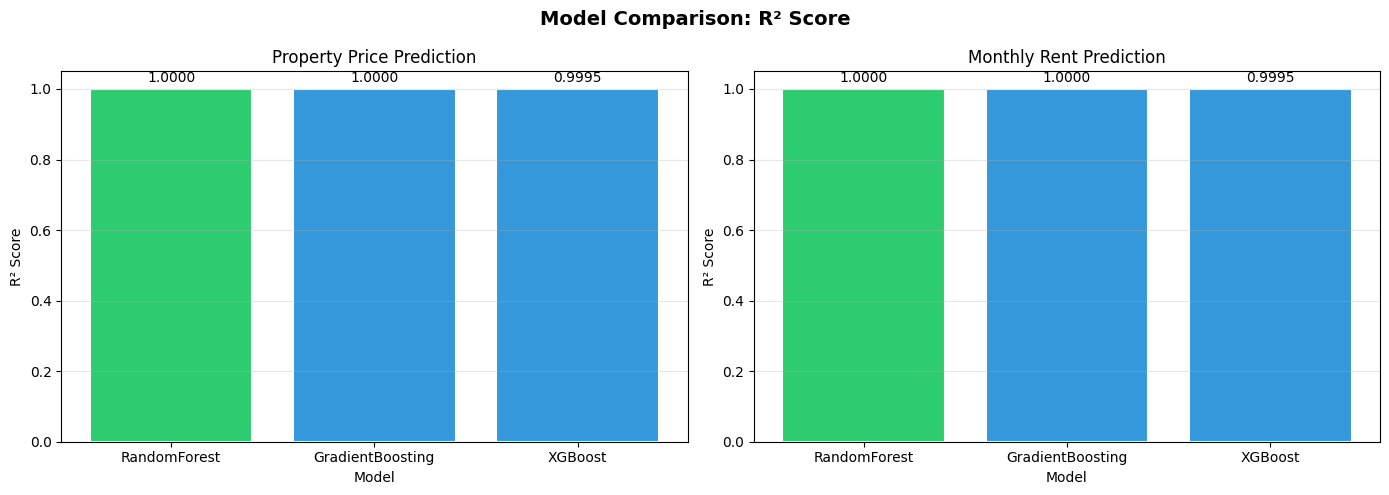

Chart saved to models/model_comparison.png


In [8]:
# ── Model comparison bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison: R² Score", fontsize=14, fontweight="bold")

for ax, (metrics, title) in zip(axes, [(price_metrics, "Property Price"), (rent_metrics, "Monthly Rent")]):
    colors = ["#2ecc71" if v == metrics["R²"].max() else "#3498db" for v in metrics["R²"]]
    bars = ax.bar(metrics.index, metrics["R²"], color=colors, edgecolor="white", linewidth=1.5)
    ax.set_title(f"{title} Prediction", fontsize=12)
    ax.set_ylabel("R² Score")
    ax.set_ylim(0, 1.05)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("Model")

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to models/model_comparison.png")

## Section 10–11: 5-Year Forecast Engine + ROI Computation + Investment Rating

In [9]:
def investment_rating(roi_pct: float) -> str:
    if roi_pct >= 80:  return "⭐⭐⭐⭐⭐  Excellent"
    if roi_pct >= 50:  return "⭐⭐⭐⭐   Very Good"
    if roi_pct >= 30:  return "⭐⭐⭐     Good"
    if roi_pct >= 10:  return "⭐⭐       Average"
    return              "⭐         Below Average"

def roi_calc(purchase_price, future_price, total_rent):
    return ((future_price + total_rent - purchase_price) / purchase_price) * 100

def five_year_forecast(purchase_price: float, monthly_rent: float,
                        price_growth: float = PRICE_GROWTH,
                        rent_growth:  float = RENT_GROWTH) -> pd.DataFrame:
    """Generate year-by-year ROI forecast table."""
    rows = []
    for yr in range(1, YEARS + 1):
        fp   = purchase_price * (1 + price_growth) ** yr
        tr   = sum(monthly_rent * (1 + rent_growth)**t * 12 for t in range(1, yr+1))
        mr   = monthly_rent * (1 + rent_growth) ** yr
        roi  = roi_calc(purchase_price, fp, tr)
        rows.append({
            "Year":                 yr,
            "Property Price (₹)":  round(fp, 0),
            "Monthly Rent (₹)":    round(mr, 0),
            "Annual Rent (₹)":     round(mr * 12, 0),
            "Total Rent Earned (₹)": round(tr, 0),
            "ROI (%)":             round(roi, 2),
            "Rating":              investment_rating(roi),
        })
    return pd.DataFrame(rows).set_index("Year")

# Quick demo
sample_forecast = five_year_forecast(purchase_price=8_500_000, monthly_rent=25_000)
print("5-Year Forecast (demo: ₹85L property, ₹25K/mo rent):")
display(sample_forecast)

5-Year Forecast (demo: ₹85L property, ₹25K/mo rent):


,Property Price (₹),Monthly Rent (₹),Annual Rent (₹),Total Rent Earned (₹),ROI (%),Rating
Year,,,,,,
1,"9,010,000.00","27,250.00","327,000.00","327,000.00",9.85,⭐ Below Average
2,"9,550,600.00","29,703.00","356,430.00","683,430.00",20.40,⭐⭐ Average
3,"10,123,636.00","32,376.00","388,509.00","1,071,939.00",31.71,⭐⭐⭐ Good
4,"10,731,054.00","35,290.00","423,474.00","1,495,413.00",43.84,⭐⭐⭐ Good
5,"11,374,917.00","38,466.00","461,587.00","1,957,000.00",56.85,⭐⭐⭐⭐ Very Good


## Section 12: `predict_roi(...)` Function

In [10]:
def prepare_input_row(inp: dict) -> pd.DataFrame:
    """Convert a property dict into a model-ready feature row."""
    price = float(inp["price"])
    rent  = float(inp["rent"])
    area  = float(inp["area"])

    row = {
        "bhk":           float(inp.get("bhk", 2)),
        "area":          area,
        "property_age":  float(inp.get("property_age", 5)),
        "floor":         float(inp.get("floor", 1)),
        "price_per_sqft": float(inp.get("price_per_sqft", price / max(area, 1))),
        "rent_per_sqft":  float(inp.get("rent_per_sqft",  rent  / max(area, 1))),
        "annual_rent":    rent * 12,
    }
    for col in CAT_COLS:
        le  = encoders[col]
        val = str(inp.get(col, "unknown"))
        if val not in le.classes_:
            val = le.classes_[0]
        row[f"{col}_enc"] = int(le.transform([val])[0])

    return pd.DataFrame([row])[FEATURE_COLS]


def predict_roi(location: str, property_type: str, bhk: int,
                area: float, price: float, rent: float,
                property_age: float = 5, floor: int = 1,
                furnishing: str = "unfurnished") -> dict:
    """
    Predict ROI and 5-year forecast for a given property.
    Returns: predicted_roi, future_property_price, total_rent_earned, investment_rating, yearly_forecast
    """
    inp = dict(location=location, property_type=property_type, bhk=bhk,
               area=area, price=price, rent=rent, property_age=property_age,
               floor=floor, furnishing=furnishing)
    X_row   = prepare_input_row(inp)
    ml_price = float(best_price_model.predict(X_row)[0])
    ml_rent  = float(best_rent_model.predict(X_row)[0])

    # Blend user value 70% + model correction 30%
    base_price = 0.70 * price + 0.30 * ml_price
    base_rent  = 0.70 * rent  + 0.30 * ml_rent

    forecast_df = five_year_forecast(base_price, base_rent)
    final_row   = forecast_df.iloc[-1]

    return {
        "predicted_roi":         final_row["ROI (%)"],
        "future_property_price": final_row["Property Price (₹)"],
        "total_rent_earned":     final_row["Total Rent Earned (₹)"],
        "investment_rating":     final_row["Rating"],
        "ml_price_estimate":     round(ml_price, 0),
        "ml_rent_estimate":      round(ml_rent,  0),
        "yearly_forecast":       forecast_df.reset_index().to_dict(orient="records"),
    }


# ── Example prediction ────────────────────────────────────────────────────────
result = predict_roi(
    location      = "Banjara Hills, Hyderabad",
    property_type = "apartment",
    bhk           = 3,
    area          = 1500,
    price         = 8_500_000,
    rent          = 25_000,
    property_age  = 5,
    floor         = 3,
    furnishing    = "semi-furnished",
)

print("=" * 55)
print("  PROPERTY ROI PREDICTION")
print("=" * 55)
print(f"  Predicted 5-Year ROI   : {result['predicted_roi']:.2f}%")
print(f"  Future Property Price  : ₹ {result['future_property_price']:>12,.0f}")
print(f"  Total Rent Earned      : ₹ {result['total_rent_earned']:>12,.0f}")
print(f"  Investment Rating      : {result['investment_rating']}")
print(f"  ML Price Estimate      : ₹ {result['ml_price_estimate']:>12,.0f}")
print(f"  ML Rent Estimate       : ₹ {result['ml_rent_estimate']:>8,.0f} /mo")
print("=" * 55)

  PROPERTY ROI PREDICTION
  Predicted 5-Year ROI   : 55.69%
  Future Property Price  : ₹   11,977,116
  Total Rent Earned      : ₹    1,957,000
  Investment Rating      : ⭐⭐⭐⭐   Very Good
  ML Price Estimate      : ₹    9,999,994
  ML Rent Estimate       : ₹   25,000 /mo


## Section 13: Year-wise 5-Year Investment Forecast Table + Chart

,Property Price (₹),Monthly Rent (₹),Annual Rent (₹),Total Rent Earned (₹),ROI (%),Rating
Year,,,,,,
1,"9,486,998.00","27,250.00","327,000.00","327,000.00",9.65,⭐ Below Average
2,"10,056,218.00","29,702.00","356,430.00","683,430.00",20.00,⭐⭐ Average
3,"10,659,591.00","32,376.00","388,509.00","1,071,939.00",31.08,⭐⭐⭐ Good
4,"11,299,166.00","35,290.00","423,474.00","1,495,413.00",42.96,⭐⭐⭐ Good
5,"11,977,116.00","38,466.00","461,587.00","1,957,000.00",55.69,⭐⭐⭐⭐ Very Good


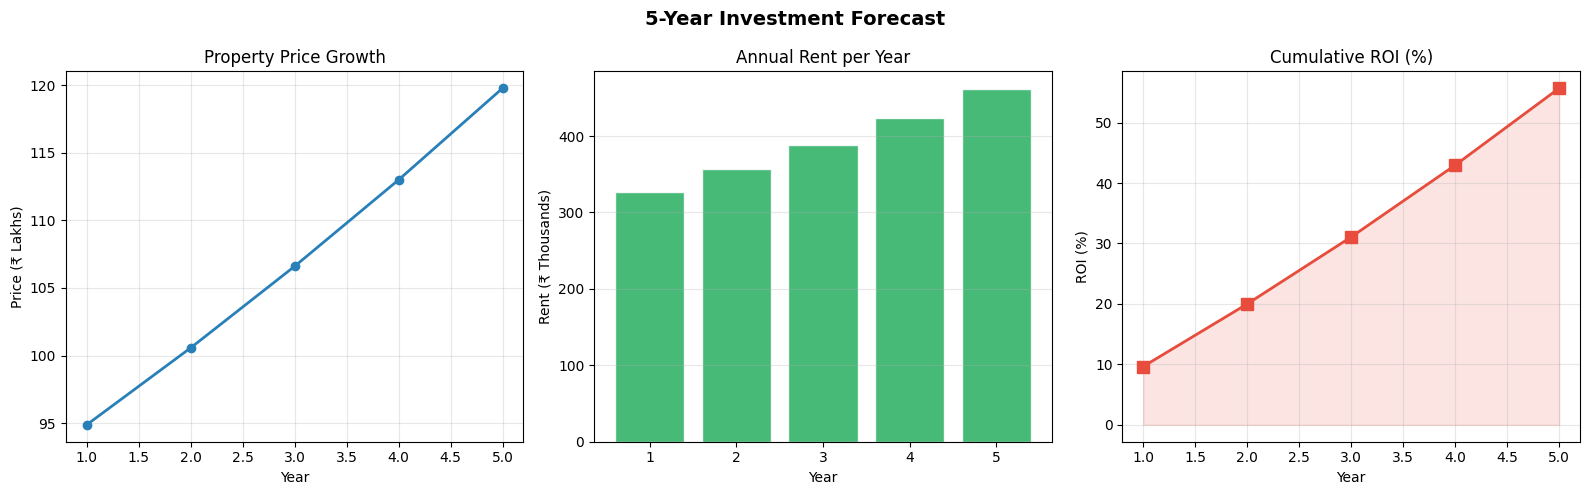

Forecast chart saved to models/forecast_chart.png


In [11]:
forecast_df = pd.DataFrame(result["yearly_forecast"]).set_index("Year")
display(forecast_df)

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("5-Year Investment Forecast", fontsize=14, fontweight="bold")

years = forecast_df.index.tolist()

axes[0].plot(years, forecast_df["Property Price (₹)"] / 1e5, "o-", color="#2980b9", lw=2)
axes[0].set_title("Property Price Growth")
axes[0].set_ylabel("Price (₹ Lakhs)")
axes[0].set_xlabel("Year")
axes[0].grid(alpha=0.3)

axes[1].bar(years, forecast_df["Annual Rent (₹)"] / 1e3, color="#27ae60", alpha=0.85, edgecolor="white")
axes[1].set_title("Annual Rent per Year")
axes[1].set_ylabel("Rent (₹ Thousands)")
axes[1].set_xlabel("Year")
axes[1].grid(axis="y", alpha=0.3)

axes[2].plot(years, forecast_df["ROI (%)"], "s-", color="#e74c3c", lw=2, markersize=8)
axes[2].fill_between(years, 0, forecast_df["ROI (%)"], alpha=0.15, color="#e74c3c")
axes[2].set_title("Cumulative ROI (%)")
axes[2].set_ylabel("ROI (%)")
axes[2].set_xlabel("Year")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/forecast_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Forecast chart saved to models/forecast_chart.png")

## Section 14: Save Model Artifacts with `joblib`

In [12]:
import json

# Save best models
joblib.dump(best_price_model, f"{MODELS_DIR}/best_price_model.joblib")
joblib.dump(best_rent_model,  f"{MODELS_DIR}/best_rent_model.joblib")
joblib.dump(encoders,         f"{MODELS_DIR}/encoders.joblib")

# Save metadata
meta = {
    "price_model": best_price_name,
    "rent_model":  best_rent_name,
    "price_r2":    round(float(price_metrics.loc[best_price_name, "R²"]), 4),
    "rent_r2":     round(float(rent_metrics.loc[best_rent_name,  "R²"]), 4),
    "feature_cols": FEATURE_COLS,
    "growth_assumptions": {
        "price_growth_pct": PRICE_GROWTH * 100,
        "rent_growth_pct":  RENT_GROWTH  * 100,
        "forecast_years":   YEARS,
    },
}
joblib.dump(meta, f"{MODELS_DIR}/model_meta.joblib")
with open(f"{MODELS_DIR}/model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("✓ Artifacts saved to models/")
for fname in os.listdir(MODELS_DIR):
    size = os.path.getsize(f"{MODELS_DIR}/{fname}")
    print(f"  {fname:<35}  {size/1024:>8.1f} KB")

# ── Load test ─────────────────────────────────────────────────────────────────
loaded_price = joblib.load(f"{MODELS_DIR}/best_price_model.joblib")
loaded_rent  = joblib.load(f"{MODELS_DIR}/best_rent_model.joblib")
test_pred    = loaded_price.predict(X_test[:3])
print(f"\nLoad test – price predictions: {test_pred.round(0)}")
print("Artifact integrity verified ✓")

✓ Artifacts saved to models/
  best_price_model.joblib               43758.0 KB
  best_rent_model.joblib                43459.5 KB
  encoders.joblib                          80.8 KB
  forecast_chart.png                       81.4 KB
  model_comparison.png                     44.0 KB
  model_meta.joblib                         0.3 KB
  model_meta.json                           0.4 KB

Load test – price predictions: [12300000.  1260582.  1310229.]
Artifact integrity verified ✓


## Section 15: FastAPI Backend — `POST /predict_roi`

The full FastAPI application is in `backend/main.py`.

**Start the server** (from the project root):
```bash
uvicorn backend.main:app --reload --port 8000
```

**Sample API call:**
```bash
curl -X POST http://localhost:8000/predict_roi \
  -H "Content-Type: application/json" \
  -d '{
    "location": "Banjara Hills, Hyderabad",
    "property_type": "apartment",
    "bhk": 3,
    "area": 1500,
    "price": 8500000,
    "rent": 25000,
    "property_age": 5,
    "floor": 3,
    "furnishing": "semi-furnished"
  }'
```

**Interactive docs:** http://localhost:8000/docs

In [13]:
import json

# Simulate what the FastAPI endpoint does (without starting a server)
sample_payload = {
    "location":      "Banjara Hills, Hyderabad",
    "property_type": "apartment",
    "bhk":           3,
    "area":          1500,
    "price":         8_500_000,
    "rent":          25_000,
    "property_age":  5,
    "floor":         3,
    "furnishing":    "semi-furnished",
}
sample_payload["price_per_sqft"] = sample_payload["price"] / sample_payload["area"]
sample_payload["rent_per_sqft"]  = sample_payload["rent"]  / sample_payload["area"]

api_result = predict_roi(**{k: v for k, v in sample_payload.items()
                             if k in predict_roi.__code__.co_varnames})

# Display JSON-style response
response_json = {
    "status": "success",
    "input_summary":     sample_payload,
    "five_year_summary": {
        "future_property_price": api_result["future_property_price"],
        "total_rent_earned":     api_result["total_rent_earned"],
        "roi_pct":               api_result["predicted_roi"],
        "investment_rating":     api_result["investment_rating"],
    },
    "yearly_forecast": api_result["yearly_forecast"],
}
print(json.dumps(
    {k: v for k, v in response_json.items() if k != "yearly_forecast"},
    indent=2
))
print(f"\n... plus yearly_forecast array with {len(response_json['yearly_forecast'])} entries.")

{
  "status": "success",
  "input_summary": {
    "location": "Banjara Hills, Hyderabad",
    "property_type": "apartment",
    "bhk": 3,
    "area": 1500,
    "price": 8500000,
    "rent": 25000,
    "property_age": 5,
    "floor": 3,
    "furnishing": "semi-furnished",
    "price_per_sqft": 5666.666666666667,
    "rent_per_sqft": 16.666666666666668
  },
  "five_year_summary": {
    "future_property_price": 11977116.0,
    "total_rent_earned": 1957000.0,
    "roi_pct": 55.69,
    "investment_rating": "\u2b50\u2b50\u2b50\u2b50   Very Good"
  }
}

... plus yearly_forecast array with 5 entries.
